Code for correlation anaylsis

In [1]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from XACs.utils.const import DATASETS
plt.rcParams['pdf.fonttype'] = 'truetype'
#plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams["font.size"] = 8
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams.update({
    "pdf.use14corefonts": True
})


In [2]:
def diversity(smarts_dict, tol):
    return len(smarts_dict.keys())/tol

def scaffold_diversity(smiles_list):
    molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    scaffolds = [MurckoScaffold.GetScaffoldForMol(mol) for mol in molecules]
    scaffold_smiles = [Chem.MolToSmiles(scaffold) for scaffold in scaffolds]
    scaffold_counts = Counter(scaffold_smiles)
    unique_scaffolds = len(scaffold_counts)
    scaffold_richness = unique_scaffolds / len(smiles_list)
    shannon_index = shannon_diversity_index(scaffold_counts.values())
    return scaffold_richness, shannon_index

def shannon_diversity_index(counts):
    total = sum(counts)
    proportions = [count / total for count in counts]
    return -sum(p * np.log(p) for p in proportions if p > 0)

def shannon_diversity(smarts_dict):
    # calculate shannon index
    shannon_index = 0
    tot_smarts = sum(smarts_dict.values())
    for smarts in smarts_dict.keys():
        p = smarts_dict[smarts]/tot_smarts
        shannon_index += -p * np.log2(p)
    return shannon_index

data_path = 'Data'
scaffold_richnesses, shannon_indexes = [],[]
size, ac_ratios = [], []
sub_richnesses, sub_shannons = [], []
for ds in DATASETS:
    save_dir = f'./{data_path}/{ds}'
    csv = pd.read_csv(f'{save_dir}/{ds}.csv')
    smiles_list = csv['smiles'].tolist()
    scaffold_richness, shannon_index = scaffold_diversity(smiles_list)
    scaffold_richnesses.append(scaffold_richness)
    shannon_indexes.append(shannon_index)
    size.append(len(smiles_list))
    ac_ratios.append(csv['cliff_mol'].tolist().count(1)/len(smiles_list))
    with open(f'{save_dir}/smarts_dict.pkl', 'rb') as f:
        smarts_dict = pickle.load(f)
    sub_richnesses.append(diversity(smarts_dict, len(smiles_list)))
    sub_shannons.append(shannon_diversity(smarts_dict))

In [3]:
# load data from csv
df_rf = pd.read_csv('./result_rf.csv')
df_gine = pd.read_csv('./result_gine.csv')
df_gat = pd.read_csv('./result_gat.csv')
df_nn=pd.read_csv('./result_nn.csv')
df_nn_mlp = pd.read_csv('./result_mlp_att.csv')
df_uncom_ablation = pd.read_csv('./result_uncom_ablation.csv')
df_com_ablation = pd.read_csv('./result_com_ablation.csv')
df_all = pd.concat([ df_gine, df_gat, df_nn], ignore_index=True)
df = df_all

In [5]:
##### Change Ratio #####
change_ratio = np.zeros((len(DATASETS), 3))
scores = ['test_rmse', 'test_cliff_rmse', 'gradcam_acc']
label = ['RMSE', r'RMSE$_{\mathrm{cliff}}$', 'GDScore']

for i, dataset in enumerate(DATASETS):
    for j, score in enumerate(scores):
        mask = (
        (df_all["metric_name"] == score) &
        (df_all["method"] != "rf") &
        (df_all["target"]      == dataset) &
        (df_all["x_supervis"]  == "no")
        )       
        avg_before = df_all.loc[mask, "metric_value"].mean()
        mask = (
        (df_all["metric_name"] == score) &
        # remove method==rf
        (df_all["method"] != "rf") &
        (df_all["target"]      == dataset) &
        (df_all["x_supervis"]  == "yes") 
        )
        avg_after = df_all.loc[mask, "metric_value"].mean()
        if score == 'gradcam_acc':
            change_ratio[i, j] = (avg_after - avg_before) / avg_before * 100
        else:
            change_ratio[i, j] = (avg_before - avg_after) / avg_before * 100

data = {
    'RMSE Improvement': change_ratio[:, 0],
    r'RMSE$_{\mathrm{cliff}}$ Improvement': change_ratio[:, 1],
    'Global Direction Improvement': change_ratio[:, 2],
    'Number of Molecules': size,
    'Ratio of AC Molecule': ac_ratios,
    'Scaffold Shannon': shannon_indexes,
    'Scaffold Diversity': scaffold_richnesses,
    'Substructure Shannon': sub_shannons,
    'Substructure Diversity': sub_richnesses
    
}

# Create a DataFrame
df = pd.DataFrame(data)

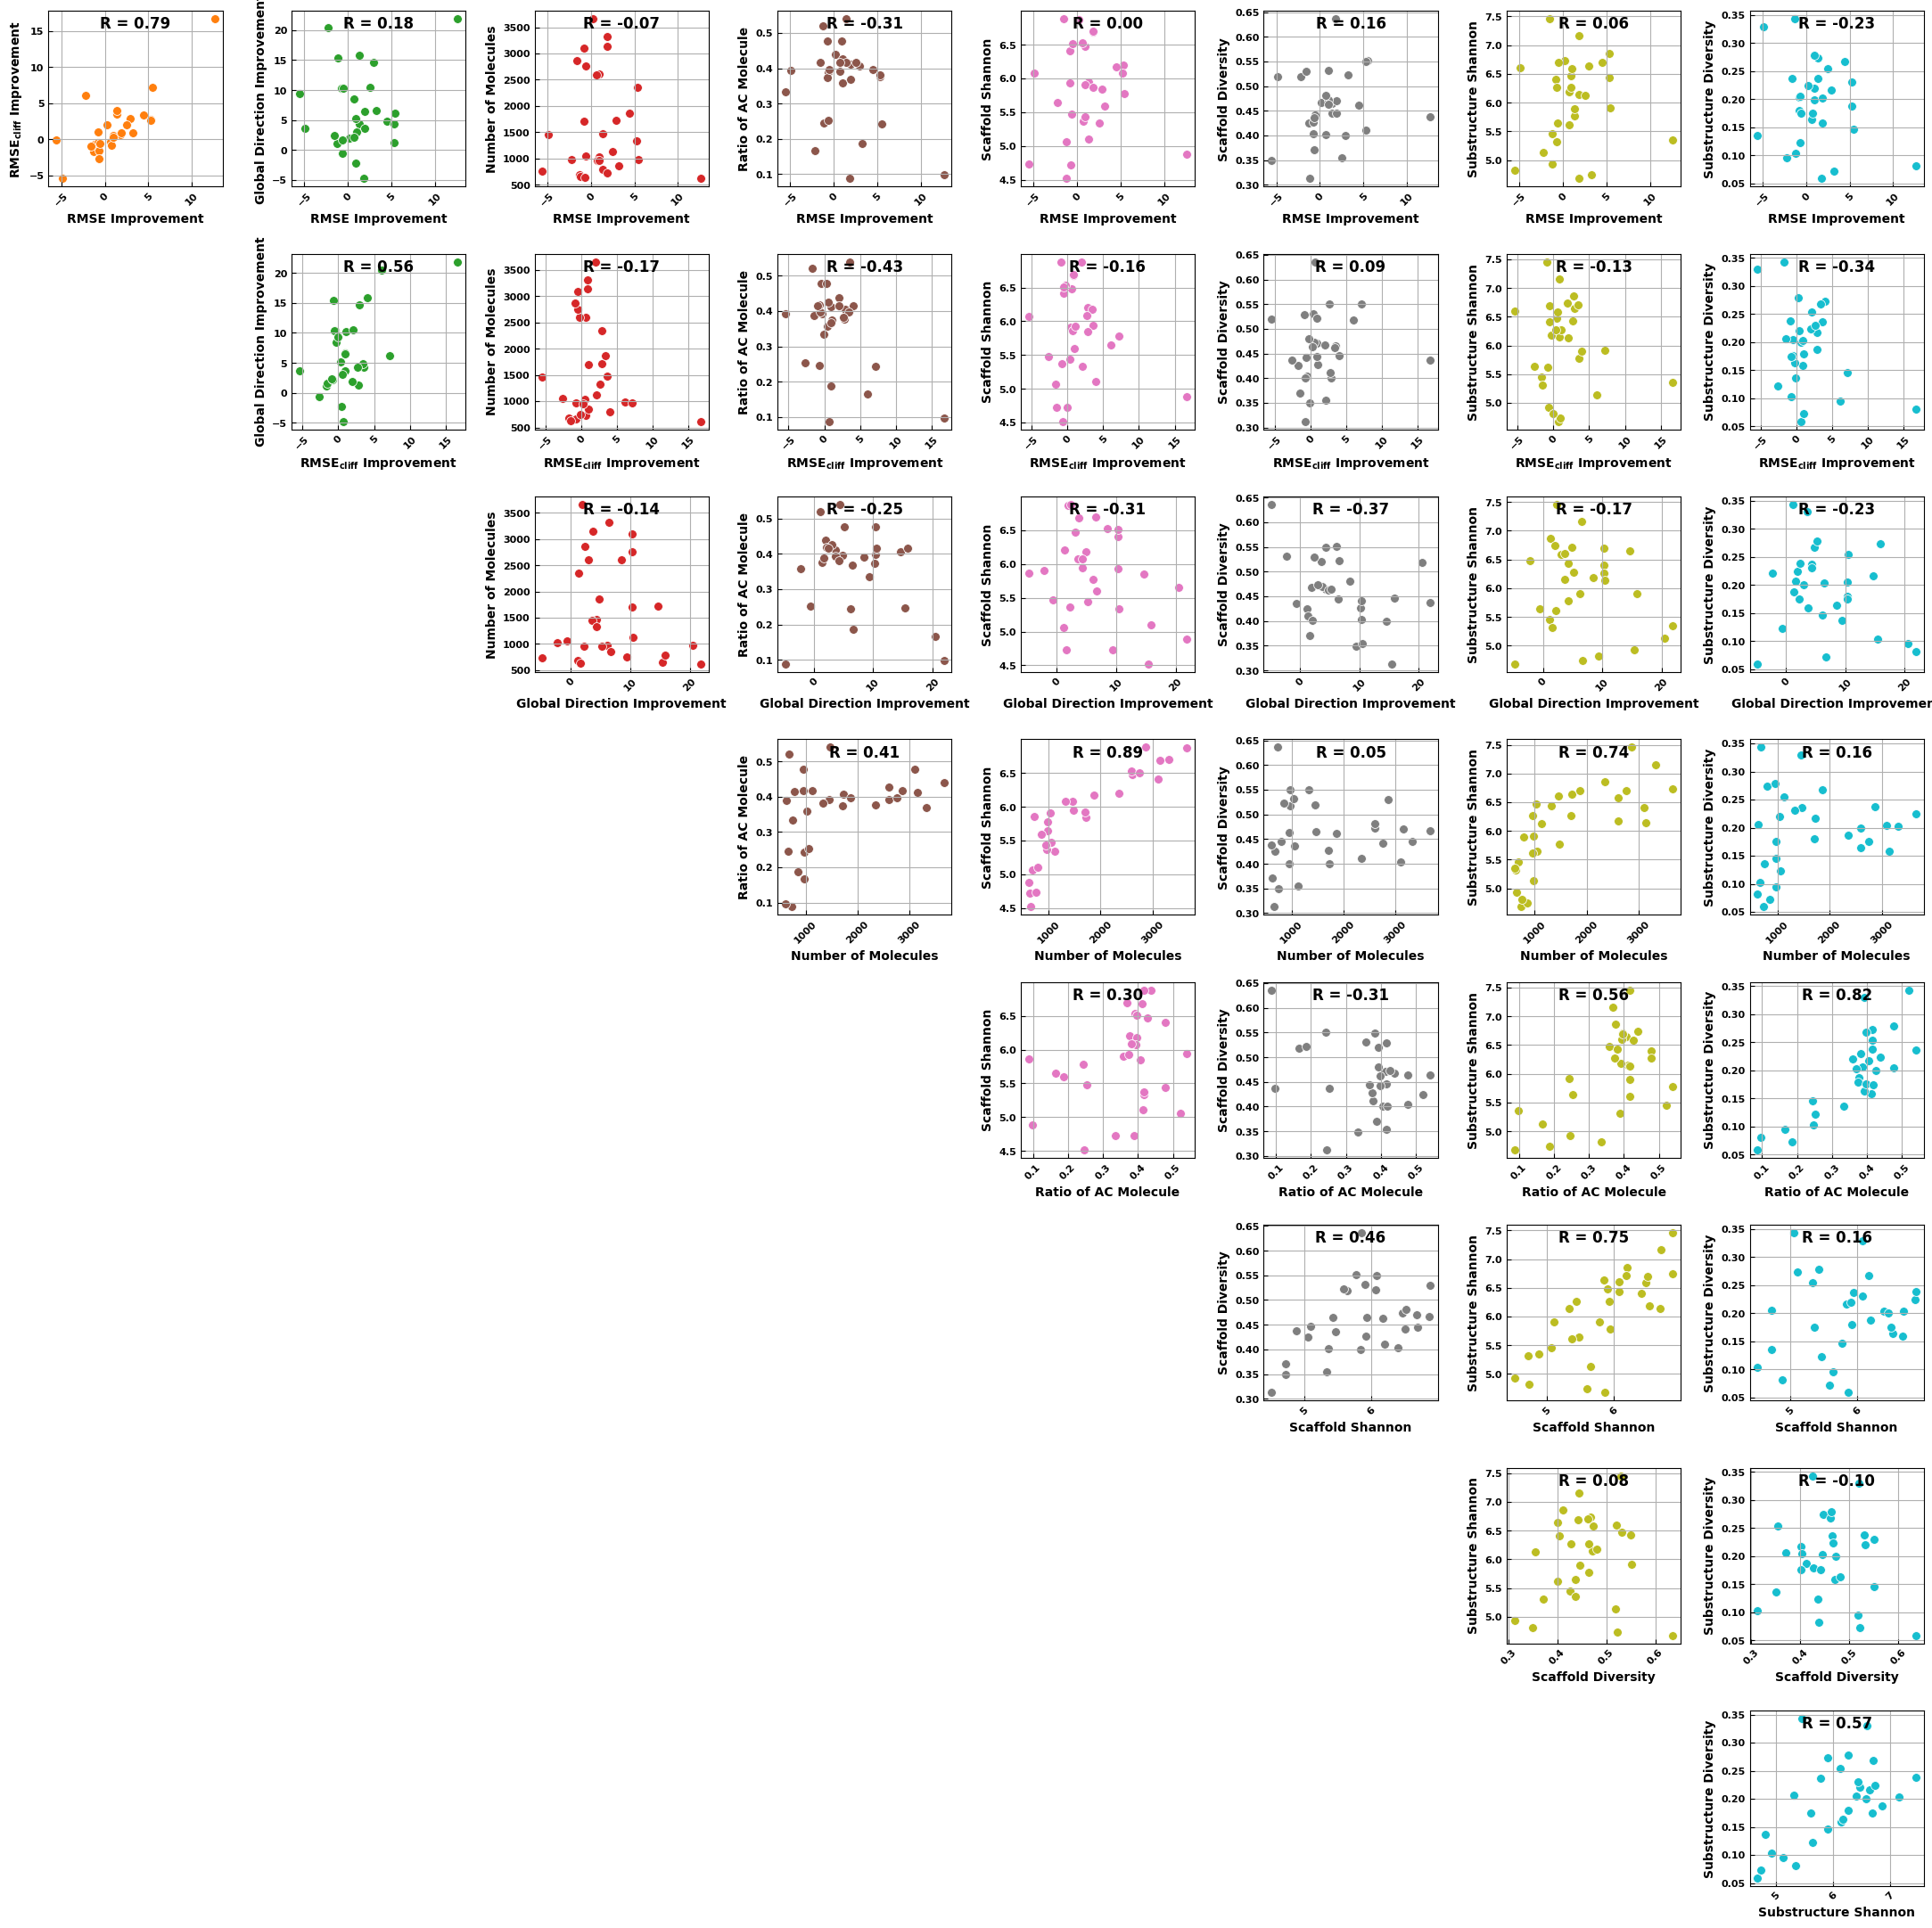

In [13]:
# Metrics list
metrics = [
    'RMSE Improvement',
    r'RMSE$_{\mathrm{cliff}}$ Improvement',
    'Global Direction Improvement',
    'Number of Molecules',
    'Ratio of AC Molecule',
    'Scaffold Shannon',
    'Scaffold Diversity',
    'Substructure Shannon',
    'Substructure Diversity'
    
]

colors = plt.cm.tab10(np.linspace(0, 1, len(metrics)))

# Initialize the figure
plt.figure(figsize=(24, 24))

for i, metric_x in enumerate(metrics):
    for j, metric_y in enumerate(metrics):
        # Only plot for the upper diagonal
        if j > i:
            ax = plt.subplot(len(metrics), len(metrics), i * len(metrics) + j + 1)
            
            # Scatter plot with a different color for each column and increased point size
            sns.scatterplot(data=df, x=metric_x, y=metric_y, ax=ax, color=colors[j], alpha=1, s=50)  # Increased point size
            
            # Calculate and display the correlation coefficient
            corr = df[[metric_x, metric_y]].corr().iloc[0, 1]
            ax.text(0.5, 0.9, f'R = {corr:.2f}', horizontalalignment='center', transform=ax.transAxes, fontsize=12)
            
            # Set labels with a smaller font size for all subplots
            ax.set_xlabel(metric_x, fontsize=10)
            ax.set_ylabel(metric_y, fontsize=10)
            
            # Set tick labels for all subplots, rotate them for better fit and reduce font size
            ax.tick_params(axis='x', labelrotation=45, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            
            # Enable grid
            ax.grid(True)

# Adjust layout to prevent label overlap
plt.tight_layout(h_pad=2.0, w_pad=2.0)
plt.show()
# save
#plt.savefig('./correlation_matrix.pdf')